In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import itertools

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# -------------------------
# Config
# -------------------------

# Path to the CSV file
# If you run on Kaggle, a common path is:
#   ../input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv
DATA_PATH = "retail_store_inventory.csv"

# Force a specific series if you want; otherwise the longest series is chosen
CHOSEN_STORE_ID = None  # e.g. "S001"
CHOSEN_PRODUCT_ID = None  # e.g. "P0005"

# Train/test split ratio (time-based)
TRAIN_FRACTION = 0.8

# ARIMA search ranges
P_RANGE = range(0, 3)  # p: 0,1,2
D_RANGE = range(0, 2)  # d: 0,1
Q_RANGE = range(0, 3)  # q: 0,1,2

RANDOM_SEED = 42

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# -------------------------
# Metrics helpers
# -------------------------

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return float(2.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)

def evaluate_forecast(y_true, y_pred):
    return {
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "wape": wape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }

def metrics_table(rows, title=None):
    df = pd.DataFrame(rows)
    if title:
        print(title)
    display(df)
    return df

print("Imports, config and helpers ready.")


Imports, config and helpers ready.


## 1. Load and clean the dataset

In [2]:

# Try a couple of common paths (local & Kaggle-style)
candidate_paths = [
    Path(DATA_PATH),
    Path("../input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv"),
]

data_path = None
for p in candidate_paths:
    if p.is_file():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the CSV file. Please check DATA_PATH or the Kaggle input path."
    )

print(f"Using data file: {data_path}")

data = pd.read_csv(data_path)
print("Raw shape:", data.shape)

# Parse dates & sort
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

# Basic cleaning for Units Sold
target_col = "Units Sold"
data[target_col] = (
    data[target_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Replace inf & drop rows with NaN in target
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=[target_col], inplace=True)

print("Cleaned shape:", data.shape)
display(data.head())


Using data file: retail_store_inventory.csv
Raw shape: (73100, 15)
Cleaned shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127.0,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81.0,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5.0,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58.0,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147.0,37,150.27,28.46,20,Sunny,1,29.40,Winter


## 2. Select a (Store ID, Product ID) time series

Top 10 series by length:


Store ID  Product ID
S001      P0001         731
          P0002         731
          P0003         731
          P0004         731
          P0005         731
          P0006         731
          P0007         731
          P0008         731
          P0009         731
          P0010         731
Name: Units Sold, dtype: int64


Auto-selected longest series:
  Store ID   : S001
  Product ID : P0001

Selected series shape: (731, 14)


,Units Sold
Date,
2022-01-01,127.0
2022-01-02,81.0
2022-01-03,5.0
2022-01-04,58.0
2022-01-05,147.0


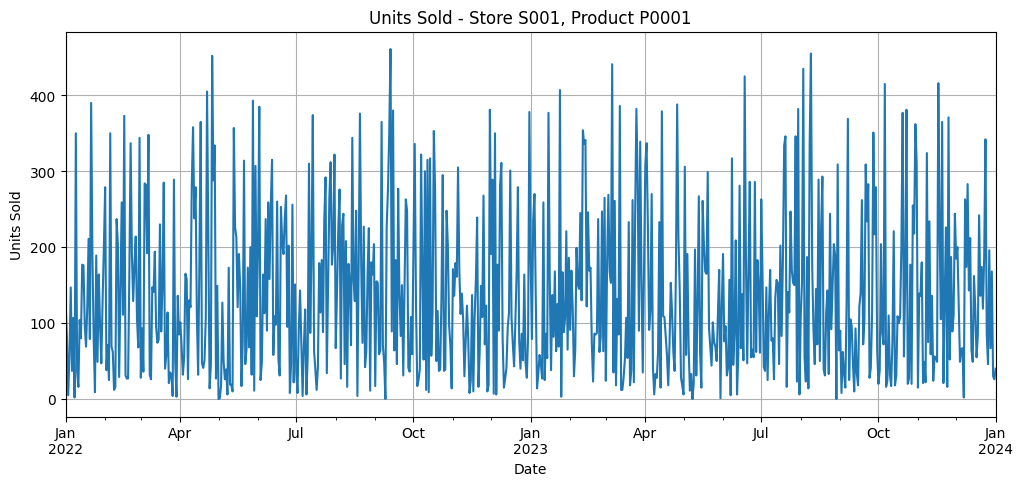

In [3]:

# Count observations per (Store, Product)
counts = (
    data.groupby(["Store ID", "Product ID"])[target_col]
    .count()
    .sort_values(ascending=False)
)

print("Top 10 series by length:")
display(counts.head(10))

if (CHOSEN_STORE_ID is None) or (CHOSEN_PRODUCT_ID is None):
    store_id, product_id = counts.index[0]
    print("\nAuto-selected longest series:")
else:
    store_id, product_id = CHOSEN_STORE_ID, CHOSEN_PRODUCT_ID
    if (store_id, product_id) not in counts.index:
        raise ValueError(f"Chosen series not found: {store_id}, {product_id}")
    print("\nUsing user-chosen series:")

print("  Store ID   :", store_id)
print("  Product ID :", product_id)

ts_df = data[(data["Store ID"] == store_id) & (data["Product ID"] == product_id)].copy()
ts_df = ts_df.sort_values("Date").set_index("Date")

# Ensure daily frequency
ts_df = ts_df.asfreq("D")

# Fill missing target with 0 (lack of sales)
ts_df[target_col] = ts_df[target_col].fillna(0.0)

print("\nSelected series shape:", ts_df.shape)
display(ts_df[[target_col]].head())

# Plot the time series
ts_df[target_col].plot(title=f"{target_col} - Store {store_id}, Product {product_id}")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.show()


## 3. Train / Test split (time-based)

Total points: 731
Train size : 584
Test size  : 147


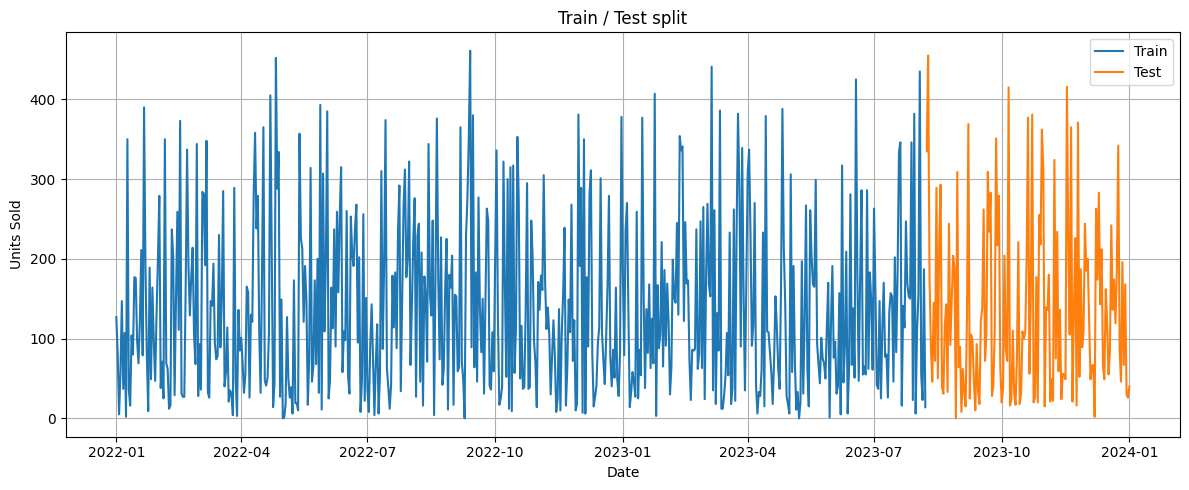

In [4]:

y = ts_df[target_col].astype(float)

n = len(y)
train_size = int(n * TRAIN_FRACTION)
train = y.iloc[:train_size]
test = y.iloc[train_size:]

print(f"Total points: {n}")
print(f"Train size : {len(train)}")
print(f"Test size  : {len(test)}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.title("Train / Test split")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Stationarity checks (ADF) and differencing

ADF Test for Original train series
  Test Statistic: -24.39621429498874
  p-value: 0.0
  #Lags Used: 0
  #Observations Used: 583
  Critical Value (1%): -3.441616425652826
  Critical Value (5%): -2.866510292004876
  Critical Value (10%): -2.5694170294713863
----------------------------------------


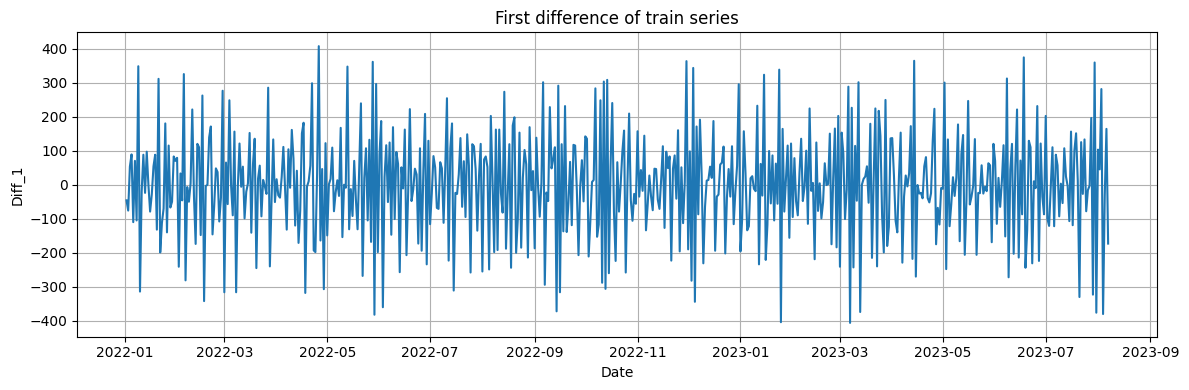

ADF Test for First difference of train series
  Test Statistic: -9.162298443429806
  p-value: 2.5139961205849476e-15
  #Lags Used: 19
  #Observations Used: 563
  Critical Value (1%): -3.4420185006698127
  Critical Value (5%): -2.8666873299250253
  Critical Value (10%): -2.5695113665058726
----------------------------------------


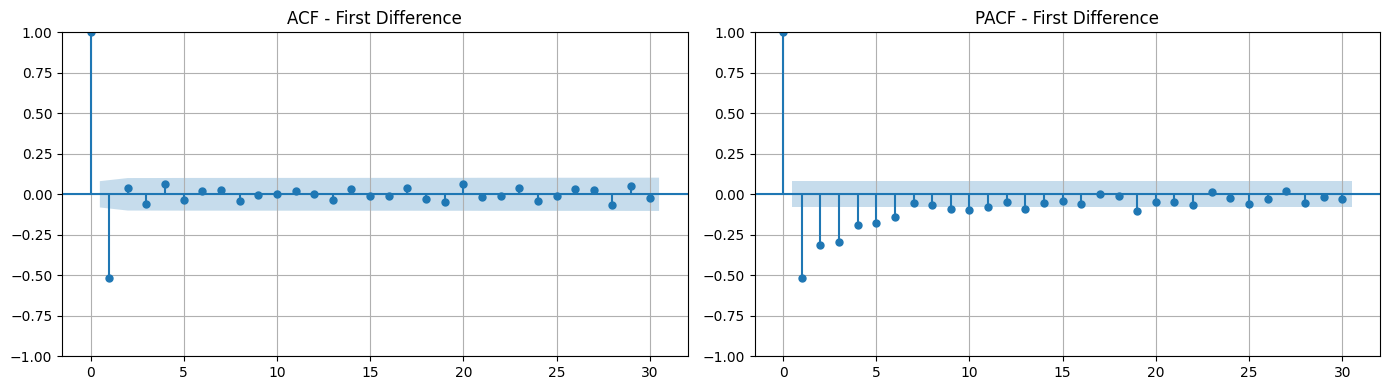

In [5]:

def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag="AIC")
    output = {
        "Test Statistic": result[0],
        "p-value": result[1],
        "#Lags Used": result[2],
        "#Observations Used": result[3],
    }
    print(f"ADF Test for {name}")
    for k, v in output.items():
        print(f"  {k}: {v}")
    for key, value in result[4].items():
        print(f"  Critical Value ({key}): {value}")
    print("-" * 40)

# ADF on train
adf_test(train, "Original train series")

# First difference
train_diff1 = train.diff()
plt.figure(figsize=(12, 4))
plt.plot(train_diff1.index, train_diff1.values)
plt.title("First difference of train series")
plt.xlabel("Date")
plt.ylabel("Diff_1")
plt.tight_layout()
plt.show()

adf_test(train_diff1, "First difference of train series")

# ACF/PACF of first difference
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff1.dropna(), ax=axes[0], lags=30)
plot_pacf(train_diff1.dropna(), ax=axes[1], lags=30, method="ywm")
axes[0].set_title("ACF - First Difference")
axes[1].set_title("PACF - First Difference")
plt.tight_layout()
plt.show()


## 5. Naive-7 baseline on Test

Naive-7 baseline metrics on Test:
{'rmse': 147.84336259685645, 'mape': 179.18386688333638, 'wape': 83.03126867157935, 'smape': 85.94081125624601}


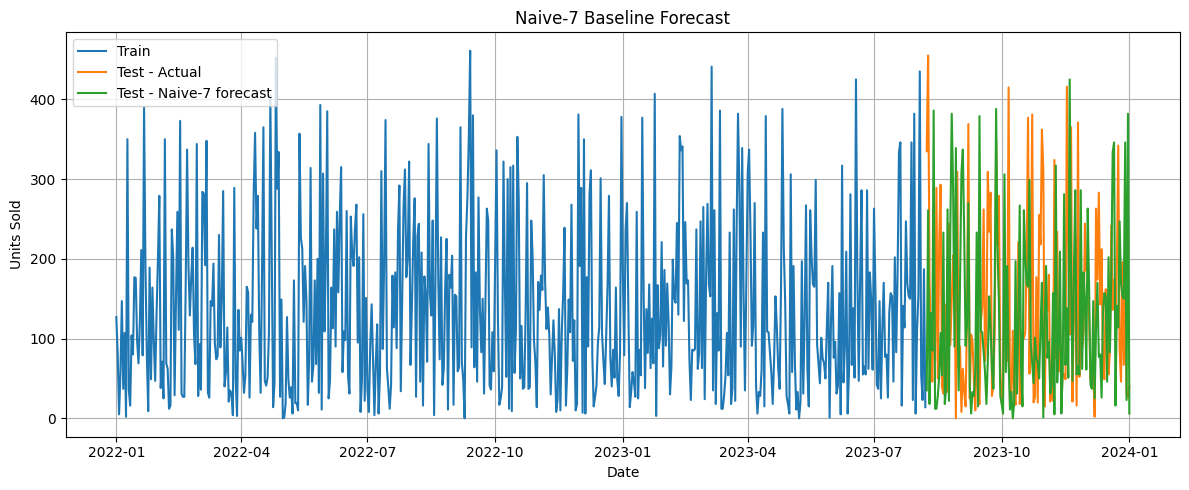

In [6]:

# Naive-7: y_hat(t) = y(t-7)
naive7 = train.shift(7).iloc[-len(test):]
naive7.index = test.index

# If some NaNs (beginning), fallback to overall mean
if naive7.isna().any():
    fallback = train.mean()
    naive7 = naive7.fillna(fallback)

baseline_metrics = evaluate_forecast(test.values, naive7.values)
print("Naive-7 baseline metrics on Test:")
print(baseline_metrics)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test - Actual")
plt.plot(test.index, naive7.values, label="Test - Naive-7 forecast")
plt.title("Naive-7 Baseline Forecast")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


## 6. ARIMA hyperparameter search over (p, d, q) using AIC

In [7]:

best_aic = np.inf
best_order = None
best_model = None

search_results = []

print("Starting ARIMA grid search...\n")
for p, d, q in itertools.product(P_RANGE, D_RANGE, Q_RANGE):
    try:
        model = ARIMA(train, order=(p, d, q))
        model_fit = model.fit()
        aic = model_fit.aic
        search_results.append({"p": p, "d": d, "q": q, "aic": aic})
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)
            best_model = model_fit
        print(f"(p,d,q)=({p},{d},{q}) -> AIC={aic:.2f}")
    except Exception as e:
        # Some combinations may fail; we just skip them
        print(f"(p,d,q)=({p},{d},{q}) failed: {e}")
        continue

print("\nGrid search complete.")
print("Best ARIMA order:", best_order, "with AIC:", best_aic)

search_df = pd.DataFrame(search_results).sort_values("aic").reset_index(drop=True)
print("\nTop ARIMA candidates by AIC:")
display(search_df.head(10))


Starting ARIMA grid search...

(p,d,q)=(0,0,0) -> AIC=7127.20
(p,d,q)=(0,0,1) -> AIC=7129.11
(p,d,q)=(0,0,2) -> AIC=7130.95
(p,d,q)=(0,1,0) -> AIC=7525.07
(p,d,q)=(0,1,1) -> AIC=7122.41
(p,d,q)=(0,1,2) -> AIC=7124.29
(p,d,q)=(1,0,0) -> AIC=7129.10
(p,d,q)=(1,0,1) -> AIC=7130.33
(p,d,q)=(1,0,2) -> AIC=7132.13
(p,d,q)=(1,1,0) -> AIC=7347.67
(p,d,q)=(1,1,1) -> AIC=7124.29
(p,d,q)=(1,1,2) -> AIC=7125.52
(p,d,q)=(2,0,0) -> AIC=7130.92
(p,d,q)=(2,0,1) -> AIC=7132.14
(p,d,q)=(2,0,2) -> AIC=7131.96
(p,d,q)=(2,1,0) -> AIC=7290.35
(p,d,q)=(2,1,1) -> AIC=7126.07
(p,d,q)=(2,1,2) -> AIC=7127.49

Grid search complete.
Best ARIMA order: (0, 1, 1) with AIC: 7122.412174915651

Top ARIMA candidates by AIC:


,p,d,q,aic
0,0,1,1,7122.412175
1,1,1,1,7124.289534
2,0,1,2,7124.291671
3,1,1,2,7125.524480
4,2,1,1,7126.067377
5,0,0,0,7127.202109
6,2,1,2,7127.488467
7,1,0,0,7129.101906
8,0,0,1,7129.106774
9,1,0,1,7130.334366


## 7. Fit best ARIMA on Train and evaluate on Test

Best model summary:


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Units Sold   No. Observations:                  584
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -3559.206
Date:                Thu, 11 Dec 2025   AIC                           7122.412
Time:                        16:53:47   BIC                           7131.149
Sample:                    01-01-2022   HQIC                          7125.817
                         - 08-07-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9988      0.026    -37.923      0.000      -1.050      -0.947
sigma2      1.164e+04    736.956     15.793      0.000    1.02e+04    1.31e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                60.95
Prob(Q):                              0.74   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.78
Prob(H) (two-sided):                  0.73   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ARIMA metrics on Test:
{'rmse': 109.59794958544236, 'mape': 211.48690794121245, 'wape': 66.37096495915131, 'smape': 72.82018563068293}
Naive-7 vs ARIMA on Test


,model,rmse,mape,wape,smape
0,Naive-7,147.843363,179.183867,83.031269,85.940811
1,"ARIMA(0, 1, 1)",109.597950,211.486908,66.370965,72.820186


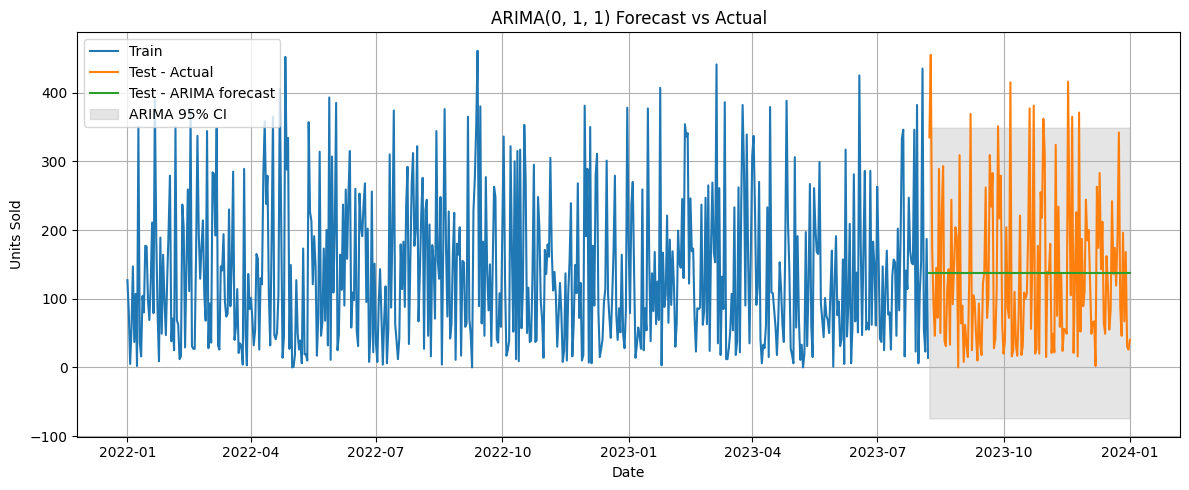

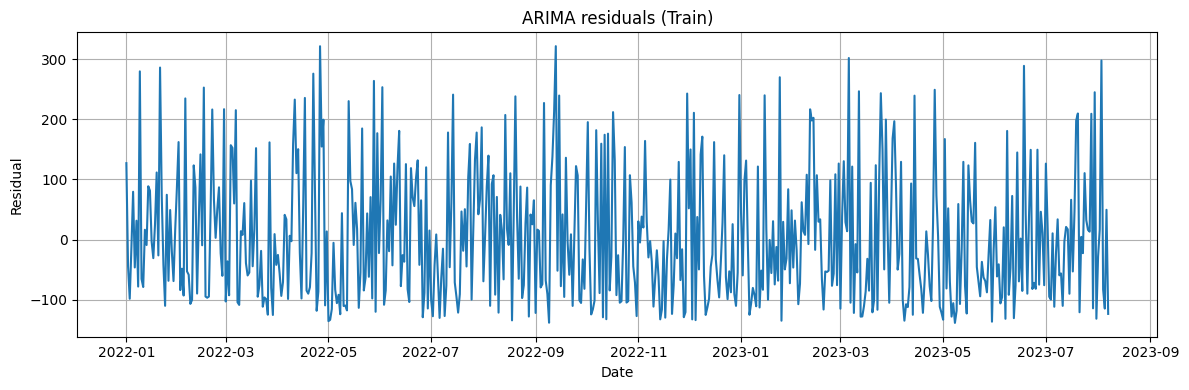

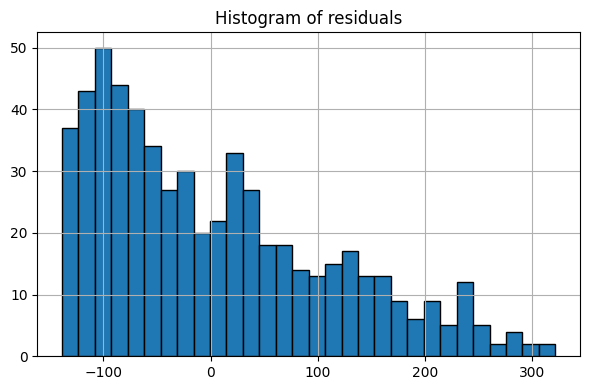

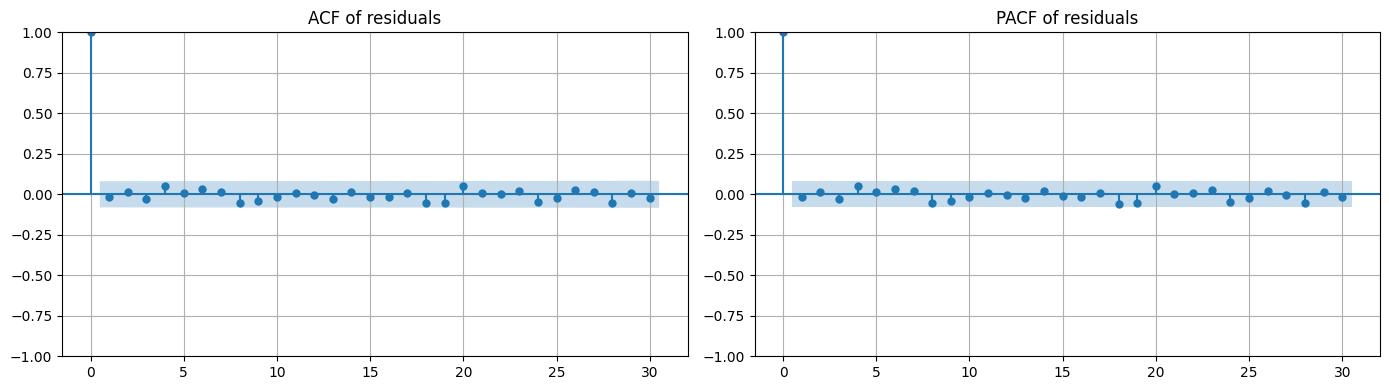

Ljung–Box test on residuals:


,lb_stat,lb_pvalue
10,6.090434,0.807609
20,11.977813,0.916838


In [8]:

if best_model is None:
    raise RuntimeError("No ARIMA model was successfully fitted in the grid search.")

print("Best model summary:")
display(best_model.summary())

# Forecast horizon = length of Test
n_test = len(test)
forecast_res = best_model.get_forecast(steps=n_test)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05)

# Align index to Test
forecast_mean.index = test.index
forecast_ci.index = test.index

# Metrics
arima_metrics = evaluate_forecast(test.values, forecast_mean.values)
print("ARIMA metrics on Test:")
print(arima_metrics)

# Combine into one DataFrame
compare_rows = [
    {
        "model": "Naive-7",
        "rmse": baseline_metrics["rmse"],
        "mape": baseline_metrics["mape"],
        "wape": baseline_metrics["wape"],
        "smape": baseline_metrics["smape"],
    },
    {
        "model": f"ARIMA{best_order}",
        "rmse": arima_metrics["rmse"],
        "mape": arima_metrics["mape"],
        "wape": arima_metrics["wape"],
        "smape": arima_metrics["smape"],
    },
]

compare_df = metrics_table(compare_rows, title="Naive-7 vs ARIMA on Test")

# Plot forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test - Actual")
plt.plot(test.index, forecast_mean.values, label="Test - ARIMA forecast")
plt.fill_between(
    test.index,
    forecast_ci.iloc[:, 0].values,
    forecast_ci.iloc[:, 1].values,
    color="gray",
    alpha=0.2,
    label="ARIMA 95% CI",
)
plt.title(f"ARIMA{best_order} Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

# Residuals on Train (in-sample)
residuals = best_model.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals.index, residuals.values)
plt.title("ARIMA residuals (Train)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals.dropna(), bins=30, edgecolor="black")
plt.title("Histogram of residuals")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals.dropna(), ax=axes[0], lags=30)
plot_pacf(residuals.dropna(), ax=axes[1], lags=30, method="ywm")
axes[0].set_title("ACF of residuals")
axes[1].set_title("PACF of residuals")
plt.tight_layout()
plt.show()

# Ljung–Box test
lb = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Ljung–Box test on residuals:")
display(lb)


## 8. Export ARIMA reports to CSV (for comparison & presentation)

In [9]:

from pathlib import Path

output_dir = Path("exports_arima")
output_dir.mkdir(exist_ok=True)
print(f"Saving ARIMA reports to: {output_dir.resolve()}")

# 1) Grid search results
search_path = output_dir / "arima_grid_search_results.csv"
search_df.to_csv(search_path, index=False)
print("Saved ARIMA grid search results ->", search_path.name)

# 2) Comparison metrics Naive-7 vs ARIMA
compare_path = output_dir / "arima_vs_naive7_test_metrics.csv"
compare_df.to_csv(compare_path, index=False)
print("Saved test metrics comparison ->", compare_path.name)

# 3) Test predictions
test_export = pd.DataFrame(
    {
        "ds": test.index,
        "y_actual": test.values,
        "y_naive7": naive7.values,
        "y_arima": forecast_mean.values,
        "y_arima_lower": forecast_ci.iloc[:, 0].values,
        "y_arima_upper": forecast_ci.iloc[:, 1].values,
    }
)
test_pred_path = output_dir / "arima_test_predictions.csv"
test_export.to_csv(test_pred_path, index=False)
print("Saved ARIMA test predictions ->", test_pred_path.name)

# 4) Full series (Train+Test) with flag for split
full_series = pd.concat([train, test], axis=0)
full_df = pd.DataFrame({"ds": full_series.index, "y": full_series.values})
full_df["split"] = ["train"] * len(train) + ["test"] * len(test)

full_path = output_dir / "arima_full_series.csv"
full_df.to_csv(full_path, index=False)
print("Saved full series ->", full_path.name)

print("\nAll ARIMA reports exported successfully.")


Saving ARIMA reports to: /content/exports_arima
Saved ARIMA grid search results -> arima_grid_search_results.csv
Saved test metrics comparison -> arima_vs_naive7_test_metrics.csv
Saved ARIMA test predictions -> arima_test_predictions.csv
Saved full series -> arima_full_series.csv

All ARIMA reports exported successfully.
